In [17]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df2024 = pd.read_csv(r".\ruea-tr-2024-ckan_mejora.csv", sep=";")
df2023 = pd.read_csv(r".\ruea-tr-2023-ckan.csv", sep=";")
df2022 = pd.read_csv(r".\ruea-tr-2022-ckan.csv", sep=";")
print("Datos listos")

Datos listos


In [19]:
contaminacion_total = pd.concat([df2022, df2023, df2024], ignore_index=True)

print(f"Dimensiones del nuevo dataset: {contaminacion_total.shape}")
display(contaminacion_total.head())

Dimensiones del nuevo dataset: (815968, 12)


,contaminantes,id_contaminantes,tipo_vehiculo,tipo_emision,ciudad,cantidad_toneladas,año,region,provincia,comuna,id_comuna,tipo_vehiculo(ccf8)
0,Nitrógeno amoniacal (o NH3),77,Vehículos particulares,Tubo de Escape Vehiculos,Iquique,"489,309,909",2022,Tarapacá,Iquique,Iquique,1101,Vehículos livianos de pasajeros gasolineros Eu...
1,Mercurio,67,Vehículos particulares,Tubo de Escape Vehiculos,Iquique,4.89E-04,2022,Tarapacá,Iquique,Iquique,1101,Vehículos livianos de pasajeros gasolineros Eu...
2,Metano (CH4),69,Vehículos particulares,Tubo de Escape Vehiculos,Iquique,"1,817,436,805",2022,Tarapacá,Iquique,Iquique,1101,Vehículos livianos de pasajeros gasolineros Eu...
3,Monóxido de carbono,73,Vehículos particulares,Tubo de Escape Vehiculos,Iquique,"1,019,806,297",2022,Tarapacá,Iquique,Iquique,1101,Vehículos livianos de pasajeros gasolineros Eu...
4,Dióxido de azufre (SO2),44,Vehículos particulares,Tubo de Escape Vehiculos,Iquique,"0,181915387",2022,Tarapacá,Iquique,Iquique,1101,Vehículos livianos de pasajeros gasolineros Eu...


In [20]:
print(contaminacion_total.dtypes)

contaminantes          object
id_contaminantes        int64
tipo_vehiculo          object
tipo_emision           object
ciudad                 object
cantidad_toneladas     object
año                     int64
region                 object
provincia              object
comuna                 object
id_comuna              object
tipo_vehiculo(ccf8)    object
dtype: object


In [21]:
df_filtrado = contaminacion_total[contaminacion_total["provincia"] == "Concepción"]

df_filtrado["comuna"].value_counts()

comuna
Concepción             6969
Coronel                6969
Lota                   6969
San Pedro de la Paz    6969
Talcahuano             6969
Hualpén                6969
Chiguayante            6171
Hualqui                6171
Penco                  6171
Tomé                   6171
Name: count, dtype: int64

In [22]:
contaminacion_total["año"].value_counts()

año
2023    390560
2022    377591
2024     47817
Name: count, dtype: int64

In [23]:
contaminacion_total.isna().sum()

contaminantes              0
id_contaminantes           0
tipo_vehiculo              0
tipo_emision               0
ciudad                     0
cantidad_toneladas         0
año                        0
region                 47817
provincia              47817
comuna                 47817
id_comuna                  0
tipo_vehiculo(ccf8)        0
dtype: int64

Aqui vemos columnas a las cuales les falta informacion ya que vienen vacias del dataset del año 2024, nuestro objetivo es poder estimar los gases en base a las comunas del Gran Concepcion, entonces lo que haremos seran los siguientes pasos:

1. Eliminar la columna region

2. Imputar nulos

3. Transformar tipos de datos

In [24]:
#Eliminar la columna region
contaminacion_total = contaminacion_total.drop(columns=["region"], errors="ignore")

In [25]:
#Tratamiento de Nulos
mascara_ciudad = contaminacion_total["ciudad"].astype(str).str.lower().str.contains("gran concepcion|gran concepción")
mascara_anio = contaminacion_total["año"] == 2024
mascara_metropolitana = mascara_ciudad & mascara_anio
contaminacion_total.loc[mascara_metropolitana, "comuna"] = "Gran Concepción (Agregado 2024)"

Otro problema que tiene este dataset, es que la columna cantidad_toneladas viene en formato string, pero nuestra meta es hacer un modelo de prediccion numerica, entonces transformaremos esos datos a decimales

In [26]:
contaminacion_total["cantidad_toneladas"] = (
    contaminacion_total["cantidad_toneladas"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)
contaminacion_total["cantidad_toneladas"] = pd.to_numeric(contaminacion_total["cantidad_toneladas"], errors="coerce")

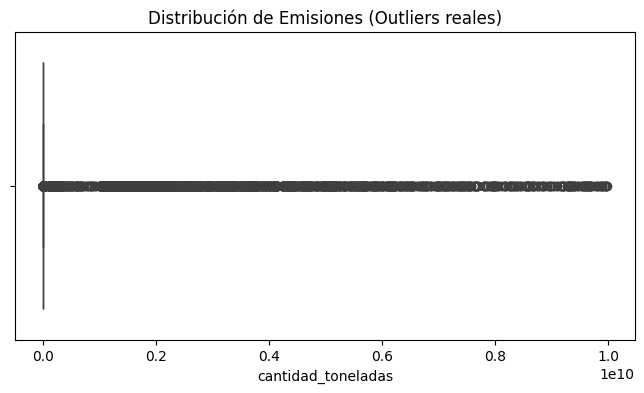

In [27]:
# 2. Tratamiento de Outliers
plt.figure(figsize=(8, 4))
sns.boxplot(x=contaminacion_total["cantidad_toneladas"])
plt.title("Distribución de Emisiones (Outliers reales)")
plt.show()

Escalado, Normalización y Codificación
Tras ver la distribución y los outliers en el boxplot de emisiones, vemos que es obligatorio aplicar una normalización logarítmica a la variable objetivo para que el modelo pueda aprender correctamente. Asimismo, debido al choque de magnitudes entre el volumen bruto de vehículos y las proporciones (tasas), se aplicará un escalado (StandardScaler) a las variables predictoras y One-Hot Encoding a las comunas.

Para mantener la integridad matemática de las sumas agrupadas y permitir el cruce exacto de strings, la ejecución de este código se realizará inmediatamente después de la creación de las nuevas features

Ahora comenzaremos con la union de los dataset

In [28]:
# 1. Cargar el dataset de permisos 
permisos_desagregados_pais = pd.read_csv(r".\permisos_desagregados_pais.csv", sep=",") 

# 2. Agrupar el dataset de emisiones
df_emisiones_agrupado = contaminacion_total.groupby(["año", "comuna"], as_index=False)["cantidad_toneladas"].sum()

# 3. Preparar y agrupar el dataset de permisos
permisos_desagregados_pais = permisos_desagregados_pais.rename(
    columns={"anio_permiso": "año", "glosa_comuna": "comuna"}
)

# Homologar el texto para evitar que el cruce falle por mayúsculas/minúsculas
permisos_desagregados_pais["comuna"] = permisos_desagregados_pais["comuna"].astype(str).str.title()
df_emisiones_agrupado["comuna"] = df_emisiones_agrupado["comuna"].astype(str).str.title()

# Contar cuántos autos hay de cada tipo de combustible por comuna/año
combustibles_por_comuna = pd.crosstab(
    [permisos_desagregados_pais["año"], permisos_desagregados_pais["comuna"]], 
    permisos_desagregados_pais["tipo_combustible"]
).reset_index()

# Contar los catalíticos y calcular no catalíticos
cataliticos_agrupado = permisos_desagregados_pais.groupby(["año", "comuna"]).agg(
    volumen_total_vehiculos=("catalitico", "count"),
    catalitico=("catalitico", "sum")
).reset_index()

cataliticos_agrupado["nocatalitico"] = cataliticos_agrupado["volumen_total_vehiculos"] - cataliticos_agrupado["catalitico"]

# Unimos las dos tablas agrupadas de los permisos
df_permisos_agrupado = pd.merge(combustibles_por_comuna, cataliticos_agrupado, on=["año", "comuna"])

# 4. INTEGRACIÓN DE FUENTES
df_master = pd.merge(df_emisiones_agrupado, df_permisos_agrupado, on=["año", "comuna"], how="inner")

# Validación de volumen
print(f"Filas Emisiones: {df_emisiones_agrupado.shape[0]}")
print(f"Filas Permisos: {df_permisos_agrupado.shape[0]}")
print(f"Filas Dataset integrado y listo: {df_master.shape[0]}")
display(df_master.head())

Filas Emisiones: 193
Filas Permisos: 1029
Filas Dataset integrado y listo: 188


,año,comuna,cantidad_toneladas,bencina,diésel,eléctrico,gas,volumen_total_vehiculos,catalitico,nocatalitico
0,2022,Alto Hospicio,679.718305,20241,17956,7,55,38259,37945,314
1,2022,Angol,459.015100,12037,5510,5,3,17555,17002,553
2,2022,Antofagasta,35787.648862,72900,25417,114,4,98435,97584,851
3,2022,Arica,515.997689,41222,33439,8,907,75576,74024,1552
4,2022,Buin,1403.395923,22536,9349,146,0,32031,31696,335


Una vez integrado ambos dataset, haremos los nuevo features

In [29]:
# Feature 1: Tasa de No Catalíticos
df_master["tasa_no_cataliticos"] = df_master["nocatalitico"] / df_master["volumen_total_vehiculos"]
df_master["tasa_no_cataliticos"] = df_master["tasa_no_cataliticos"].fillna(0)

# Feature 2: Carga de Emisión Pesada 
df_master["tasa_diesel"] = df_master["diésel"] / df_master["volumen_total_vehiculos"]
df_master["tasa_diesel"] = df_master["tasa_diesel"].fillna(0)

display(df_master[["año", "comuna", "tasa_no_cataliticos", "tasa_diesel"]].head())

,año,comuna,tasa_no_cataliticos,tasa_diesel
0,2022,Alto Hospicio,0.008207,0.469327
1,2022,Angol,0.031501,0.313871
2,2022,Antofagasta,0.008645,0.258211
3,2022,Arica,0.020536,0.442455
4,2022,Buin,0.010459,0.291873


In [30]:
from sklearn.preprocessing import StandardScaler

# 1. NORMALIZACIÓN
# Motivo: El boxplot previo demostró asimetría positiva extrema. 
# Se aplica transformación logarítmica (np.log1p) para comprimir los valores gigantes 
df_master["emisiones_log"] = np.log1p(df_master["cantidad_toneladas"])


# 2. ESCALADO
# Motivo: Choque de magnitudes. 'volumen_total_vehiculos' está en el orden de miles o millones, 
# mientras que 'tasa_no_cataliticos' y 'tasa_diesel' están entre 0 y 1. 
escalador = StandardScaler()
features_numericas = ["volumen_total_vehiculos", "tasa_no_cataliticos", "tasa_diesel"]

for col in features_numericas:
    df_master[f"{col}_escalada"] = escalador.fit_transform(df_master[[col]])


# 3. CODIFICACIÓN / ENCODING 
df_master_modelado = pd.get_dummies(df_master, columns=["comuna"], drop_first=True)

# Visualizamos cómo quedó el dataset final listo para la fase de entrenamiento
display(df_master_modelado.head())

,año,cantidad_toneladas,bencina,diésel,eléctrico,gas,volumen_total_vehiculos,catalitico,nocatalitico,tasa_no_cataliticos,...,comuna_Temuco,comuna_Tiltil,comuna_Tomé,comuna_Valdivia,comuna_Valparaíso,comuna_Vilcún,comuna_Villa Alemana,comuna_Vitacura,comuna_Viña Del Mar,comuna_Ñuñoa
0,2022,679.718305,20241,17956,7,55,38259,37945,314,0.008207,...,False,False,False,False,False,False,False,False,False,False
1,2022,459.015100,12037,5510,5,3,17555,17002,553,0.031501,...,False,False,False,False,False,False,False,False,False,False
2,2022,35787.648862,72900,25417,114,4,98435,97584,851,0.008645,...,False,False,False,False,False,False,False,False,False,False
3,2022,515.997689,41222,33439,8,907,75576,74024,1552,0.020536,...,False,False,False,False,False,False,False,False,False,False
4,2022,1403.395923,22536,9349,146,0,32031,31696,335,0.010459,...,False,False,False,False,False,False,False,False,False,False
